## SMS Spam Classifier: Multinomial Naive Bayes

The notebook is divided into the following sections:
1. Importing and preprocessing data
2. Building the model: Multinomial Naive Bayes
    - Model building 
    - Model evaluation

### 1. Importing and Preprocessing Data

In [1]:
import pandas as pd

# reading the training data
# docs = pd.read_table('SMSSpamCollection', header=None, names=['Class', 'sms'])
# docs.head()

# training data
docs = pd.read_csv('./movie_review_train.csv')
docs.rename(columns={'class': 'Class'}, inplace=True)

docs

,Class,text
0,Pos,a common complaint amongst film critics is ...
1,Pos,whew this film oozes energy the kind of b...
2,Pos,steven spielberg s amistad which is bas...
3,Pos,he has spent his entire life in an awful litt...
4,Pos,being that it is a foreign language film with...
...,...,...
1595,Neg,if anything stigmata should be taken as...
1596,Neg,john boorman s zardoz is a goofy cinemati...
1597,Neg,the kids in the hall are an acquired taste ...
1598,Neg,there was a time when john carpenter was a gr...


In [2]:
# number of SMSes / documents
len(docs)

1600

In [3]:
# counting spam and ham instances
ham_spam = docs.Class.value_counts()
ham_spam

Class
Pos    800
Neg    800
Name: count, dtype: int64

In [4]:
print("spam rate is about {0}%".format(
    round((ham_spam[1]/float(ham_spam[0]+ham_spam[1]))*100), 2))

spam rate is about 50%


/var/folders/kk/vsk5n5vj28n42f90qn__wm7w0000gn/T/ipykernel_14847/207972837.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  round((ham_spam[1]/float(ham_spam[0]+ham_spam[1]))*100), 2))


In [5]:
# mapping labels to 0 and 1
docs['label'] = docs.Class.map({'Pos':0, 'Neg':1})

In [6]:
docs.head()

,Class,text,label
0,Pos,a common complaint amongst film critics is ...,0
1,Pos,whew this film oozes energy the kind of b...,0
2,Pos,steven spielberg s amistad which is bas...,0
3,Pos,he has spent his entire life in an awful litt...,0
4,Pos,being that it is a foreign language film with...,0


In [7]:
# we can now drop the column 'Class'
docs = docs.drop('Class', axis=1)
docs.head()

,text,label
0,a common complaint amongst film critics is ...,0
1,whew this film oozes energy the kind of b...,0
2,steven spielberg s amistad which is bas...,0
3,he has spent his entire life in an awful litt...,0
4,being that it is a foreign language film with...,0


In [9]:
# convert to X and y
X = docs.text
y = docs.label
print(X.shape)
print(y.shape)

(1600,)
(1600,)


In [10]:
# splitting into test and train
from sklearn.model_selection  import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [11]:
X_train.head()

1145     this movie about two dysfunctional families n...
73       felix   sami bouajila     the siege     lives...
446      vampire lore and legend has always been a pop...
399      kevin smith is like a big kid    his humor is...
647      bruce lee was a bigger than life martial arti...
Name: text, dtype: object

In [12]:
y_train.head()

1145    1
73      0
446     0
399     0
647     0
Name: label, dtype: int64

In [13]:
# vectorizing the sentences; removing stop words
from sklearn.feature_extraction.text import CountVectorizer
vect = CountVectorizer(stop_words='english')

In [14]:
vect.fit(X_train)

CountVectorizer(stop_words='english')

In [16]:
vect.vocabulary_

31849


{'movie': 18546,
 'dysfunctional': 8768,
 'families': 10177,
 'really': 22761,
 'gets': 11728,
 'ground': 12343,
 'despite': 7542,
 'good': 12030,
 'performances': 20704,
 'basically': 2466,
 'competent': 5636,
 'cast': 4442,
 'eddie': 8868,
 'sean': 24854,
 'penn': 20645,
 'maureen': 17485,
 'robin': 23922,
 'wright': 31536,
 'happily': 12699,
 'married': 17322,
 'couple': 6336,
 'luck': 16831,
 'living': 16568,
 'rented': 23298,
 'rooms': 24044,
 'seedier': 24921,
 'unnamed': 29896,
 'city': 5089,
 'spend': 26480,
 'little': 16550,
 'income': 14176,
 'local': 16600,
 'bar': 2368,
 'owned': 20137,
 'shorty': 25433,
 'stanton': 26812,
 'best': 2843,
 'friend': 11243,
 'wife': 31212,
 'georgie': 11696,
 'mazar': 17510,
 'share': 25243,
 'odd': 19539,
 'relationship': 23156,
 'marked': 17291,
 'frequent': 11220,
 'disappearances': 7869,
 'return': 23608,
 'promises': 21985,
 'world': 31467,
 'professes': 21915,
 'undying': 29710,
 'love': 16773,
 'manic': 17182,
 'reunions': 23615,
 'soo

In [17]:
# vocab size
len(vect.vocabulary_.keys())

31849

In [125]:
# transforming the train and test datasets
X_train_transformed = vect.transform(X_train)
X_test_transformed = vect.transform(X_test)

In [126]:
# note that the type is transformed (sparse) matrix
print(type(X_train_transformed))
print(X_train_transformed)

<class 'scipy.sparse.csr.csr_matrix'>
  (0, 50)	1
  (0, 264)	1
  (0, 509)	1
  (0, 1527)	1
  (0, 1971)	1
  (0, 2780)	2
  (0, 3089)	1
  (0, 3763)	1
  (0, 3852)	1
  (0, 4248)	1
  (0, 4624)	1
  (0, 4626)	1
  (0, 4818)	1
  (0, 4822)	1
  (0, 5027)	1
  (0, 5310)	1
  (0, 6673)	1
  (1, 2169)	1
  (1, 6028)	1
  (1, 6545)	1
  (2, 98)	1
  (2, 563)	1
  (2, 1867)	1
  (2, 2436)	1
  (2, 3180)	1
  :	:
  (4176, 3879)	1
  (4176, 4417)	1
  (4176, 5229)	1
  (4176, 6191)	1
  (4176, 7134)	1
  (4177, 254)	1
  (4177, 307)	1
  (4177, 358)	1
  (4177, 831)	1
  (4177, 2046)	1
  (4177, 2704)	1
  (4177, 3585)	1
  (4177, 3623)	1
  (4177, 4130)	1
  (4177, 4315)	1
  (4177, 4771)	1
  (4177, 5234)	1
  (4177, 5321)	1
  (4177, 5487)	1
  (4177, 5620)	1
  (4177, 6321)	1
  (4177, 6374)	1
  (4177, 6453)	1
  (4178, 1643)	1
  (4178, 5817)	1


### 2. Building and Evaluating the Model

In [127]:
# training the NB model and making predictions
from sklearn.naive_bayes import MultinomialNB
mnb = MultinomialNB()

# fit
mnb.fit(X_train_transformed,y_train)

# predict class
y_pred_class = mnb.predict(X_test_transformed)

# predict probabilities
y_pred_proba = mnb.predict_proba(X_test_transformed)


In [143]:
# note that alpha=1 is used by default for smoothing
mnb

MultinomialNB(alpha=1.0, class_prior=None, fit_prior=True)

### Model Evaluation

In [129]:
# printing the overall accuracy
from sklearn import metrics
metrics.accuracy_score(y_test, y_pred_class)

0.9877961234745154

In [145]:
# confusion matrix
metrics.confusion_matrix(y_test, y_pred_class)
# help(metrics.confusion_matrix)

array([[1201,    7],
       [  10,  175]])

In [131]:
confusion = metrics.confusion_matrix(y_test, y_pred_class)
print(confusion)
TN = confusion[0, 0]
FP = confusion[0, 1]
FN = confusion[1, 0]
TP = confusion[1, 1]

[[1201    7]
 [  10  175]]


In [132]:
sensitivity = TP / float(FN + TP)
print("sensitivity",sensitivity)

sensitivity 0.9459459459459459


In [133]:
specificity = TN / float(TN + FP)
print("specificity",specificity)

specificity 0.9942052980132451


In [134]:
precision = TP / float(TP + FP)
print("precision",precision)
print(metrics.precision_score(y_test, y_pred_class))

precision 0.9615384615384616
0.9615384615384616


In [135]:
print("precision",precision)
print("PRECISION SCORE :",metrics.precision_score(y_test, y_pred_class))
print("RECALL SCORE :", metrics.recall_score(y_test, y_pred_class))
print("F1 SCORE :",metrics.f1_score(y_test, y_pred_class))

precision 0.9615384615384616
PRECISION SCORE : 0.9615384615384616
RECALL SCORE : 0.9459459459459459
F1 SCORE : 0.9536784741144414


In [136]:
y_pred_class

array([0, 0, 0, ..., 0, 1, 0])

In [137]:
y_pred_proba

array([[9.95239557e-01, 4.76044325e-03],
       [9.99852357e-01, 1.47642544e-04],
       [9.27878579e-01, 7.21214213e-02],
       ...,
       [9.99999671e-01, 3.28799076e-07],
       [3.72703622e-09, 9.99999996e-01],
       [9.99999985e-01, 1.46852511e-08]])

In [138]:
# creating an ROC curve
from sklearn.metrics import confusion_matrix as sk_confusion_matrix
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred_proba[:,1])
roc_auc = auc(false_positive_rate, true_positive_rate)

In [139]:
# area under the curve
print (roc_auc)

0.9921872203329157


In [140]:
# matrix of thresholds, tpr, fpr
pd.DataFrame({'Threshold': thresholds, 
              'TPR': true_positive_rate, 
              'FPR':false_positive_rate
             })

,FPR,TPR,Threshold
0,0.000000,0.000000,2.000000e+00
1,0.000000,0.308108,1.000000e+00
2,0.000000,0.313514,1.000000e+00
3,0.000000,0.335135,1.000000e+00
4,0.000000,0.340541,1.000000e+00
5,0.000000,0.351351,1.000000e+00
6,0.000000,0.367568,1.000000e+00
7,0.000000,0.400000,1.000000e+00
8,0.000000,0.410811,1.000000e+00
9,0.000000,0.594595,1.000000e+00


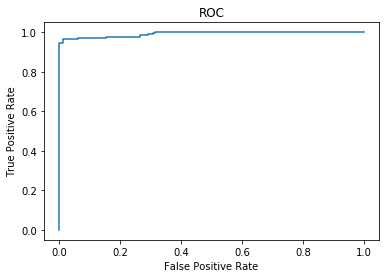

In [141]:
# plotting the ROC curve
%matplotlib inline  
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title('ROC')
plt.plot(false_positive_rate, true_positive_rate)